# Проект: исследование покупательской активности

В рамках данного проекта ставится задача разработки комплексного решения, основанного на анализе данных и бизнес-моделировании, которое позволит прогнозировать снижение покупательской активности и предлагать целевые меры по удержанию клиентов. Основной целью является создание модели, способной предсказывать вероятность снижения активности постоянных клиентов в ближайшие три месяца, а также выделение сегментов покупателей для разработки персонализированных стратегий. Для достижения этой цели необходимо выполнить несколько ключевых задач: маркировка уровня финансовой активности клиентов («снизилась» или «прежний уровень»), сбор и интеграция данных по четырём группам признаков (коммуникация с клиентом, продуктовое поведение, покупательское поведение и поведение на сайте), построение предиктивной модели с использованием современных методов машинного обучения, анализ прибыльности клиентов и разработка сегментированных рекомендаций. Особое внимание уделяется обоснованию каждого этапа решения на основе данных, что соответствует подходу руководства компании, ориентированного на аналитику и основанные на фактах решения. Результаты проекта должны не только повысить точность прогнозирования оттока клиентов, но и предоставить практические рекомендации для повышения покупательской активности, что напрямую скажется на финансовых показателях компании и её конкурентоспособности на рынке.

Загрузка необходимых для работы библиотек

In [1]:
import sys
!{sys.executable} -m pip install shap

  Using cached shap-0.51.0-cp314-cp314-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp314-cp314-win_amd64.whl (559 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl (39.2 MB)
Using cached numba-0.65.1-cp314-cp314-win_amd64.whl (2.8 MB)

   ------------- -------------------------- 2/6 [llvmlite]
   ------------- -------------------------- 2/6 [llvmlite]
   ------------- -------------------------- 2/6 [llvmlite]
   -------------------------- ------------- 4/6 [numba]
   -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install phik


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

# загружаем необходимые инструменты
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#from dython.nominal import associations
# загружаем классы для преобразования данных
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder, 
    StandardScaler, 
    MinMaxScaler,
    RobustScaler
)
 
# загружаем инструмент для автоподбора гиперпараметров
# выбор гридсерч мотивирован неограниченностью времени и ресурсов в рамках учебного проекта, в ином случае бы использовал Random
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# загружаем нужные метрики
from sklearn.metrics import roc_auc_score
import shap
# импортируем модели
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

## Загрузка данных

In [4]:
market_file_df = pd.read_csv('market_file.csv')
market_money_df = pd.read_csv('market_money.csv')
market_time_df = pd.read_csv('market_time.csv')
money_df = pd.read_csv('money.csv', sep=';', decimal=',')

In [5]:
market_file_df

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11
1296,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9
1297,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7
1298,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7


In [6]:
market_money_df

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
...,...,...,...
3895,216646,препредыдущий_месяц,4725.0
3896,216646,предыдущий_месяц,4923.0
3897,216647,предыдущий_месяц,4720.0
3898,216647,препредыдущий_месяц,5183.0


In [7]:
market_time_df

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
...,...,...,...
2595,216645,текущий_месяц,18
2596,216646,предыдцщий_месяц,18
2597,216646,текущий_месяц,7
2598,216647,текущий_месяц,10


In [8]:
money_df

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
...,...,...
1295,216643,4.44
1296,216644,6.11
1297,216645,3.29
1298,216646,4.03


Приведение столбцов к единому стандарту

In [9]:
market_file_df = market_file_df.rename(columns=lambda x: x.lower().replace(' ', '_'))
market_money_df = market_money_df.rename(columns=lambda x: x.lower().replace(' ', '_'))
market_time_df = market_time_df.rename(columns=lambda x: x.lower().replace(' ', '_'))
money_df = money_df.rename(columns=lambda x: x.lower().replace(' ', '_'))

## Предобработка данных

### Пропуски в данных

In [10]:
print(market_file_df.isna().sum())
print(market_money_df.isna().sum())
print(market_time_df.isna().sum())
print(money_df.isna().sum())

id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64
id         0
период     0
выручка    0
dtype: int64
id        0
период    0
минут     0
dtype: int64
id         0
прибыль    0
dtype: int64


### Неявные дубликаты

In [11]:
print(f"покупательская_активность: {market_file_df['покупательская_активность'].unique()}")
print(f"тип_сервиса: {market_file_df['тип_сервиса'].unique()}")
print(f"разрешить_сообщать: {market_file_df['разрешить_сообщать'].unique()}")
print(f"популярная_категория: {market_file_df['популярная_категория'].unique()}")

покупательская_активность: <StringArray>
['Снизилась', 'Прежний уровень']
Length: 2, dtype: str
тип_сервиса: <StringArray>
['премиум', 'стандартт', 'стандарт']
Length: 3, dtype: str
разрешить_сообщать: <StringArray>
['да', 'нет']
Length: 2, dtype: str
популярная_категория: <StringArray>
[                    'Товары для детей',
                    'Домашний текстиль',
                'Косметика и аксесуары',
       'Техника для красоты и здоровья',
                      'Кухонная посуда',
 'Мелкая бытовая техника и электроника']
Length: 6, dtype: str


In [12]:
market_file_df['тип_сервиса'] = market_file_df['тип_сервиса'].replace('стандартт', 'стандарт')

In [13]:
market_time_df['период'].unique()

<StringArray>
['текущий_месяц', 'предыдцщий_месяц']
Length: 2, dtype: str

In [14]:
market_time_df['период'] = market_time_df['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')

In [15]:
market_money_df['период'].unique()

<StringArray>
['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц']
Length: 3, dtype: str

### Явные дубликаты

In [16]:
print(market_file_df.duplicated().sum())
print(market_money_df.duplicated().sum())
print(market_time_df.duplicated().sum())
print(money_df.duplicated().sum())

0
0
0
0


### Типы данных

In [17]:
market_file_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   str    
 2   тип_сервиса                          1300 non-null   str    
 3   разрешить_сообщать                   1300 non-null   str    
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   str    
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                       1300

In [18]:
market_time_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2600 non-null   int64
 1   период  2600 non-null   str  
 2   минут   2600 non-null   int64
dtypes: int64(2), str(1)
memory usage: 61.1 KB


In [19]:
market_money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   str    
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 91.5 KB


In [20]:
money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


### Выводы по этапу

После проверки данных выявлено отсутствие пропусков и дубликатов во всех таблицах, что подтверждает их целостность. В ходе обработки некорректных значений в столбце "тип_сервиса" исправлены опечатки (например, "стандартт" заменен на "стандарт"), а уникальные значения категориальных признаков соответствуют ожидаемым бизнес-правилам. Типы данных в таблицах корректны: числовые признаки представлены в формате int64/float64, категориальные — в object, при этом все колонки содержат 1300 ненулевых записей в market_file_df, что соответствует заявленному объему данных. Проверка структуры таблиц подтверждает соответствие реальным данным: в market_money_df и market_time_df присутствуют периоды "текущий_месяц", "предыдущий_месяц" и т.д., что позволяет корректно агрегировать информацию для последующего анализа. Таким образом, данные готовы к объединению и моделированию без необходимости дополнительной очистки.

## Исследовательский анализ данных

### Количественные признаки

In [21]:
market_money_wide = market_money_df.pivot_table(
    index='id',
    columns='период',
    values='выручка',
    aggfunc='first'
).reset_index()

market_money_wide.columns = ['id'] + [f'выручка_{col}' for col in market_money_wide.columns[1:]]
market_money_wide = market_money_wide.fillna(0)
market_money_wide['выручка_sum'] = market_money_wide['выручка_предыдущий_месяц']+(
    market_money_wide['выручка_препредыдущий_месяц'] + market_money_wide['выручка_текущий_месяц'])
market_money_wide_filtered = market_money_wide.drop(market_money_wide[market_money_wide['выручка_sum'] == 0].index)
market_money_wide_filtered = market_money_wide_filtered.drop('выручка_sum', axis=1)
market_money_wide_filtered.head(3)

,id,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215348,0.0,0.0,3293.1
1,215349,5216.0,4472.0,4971.6
2,215350,5457.5,4826.0,5058.4


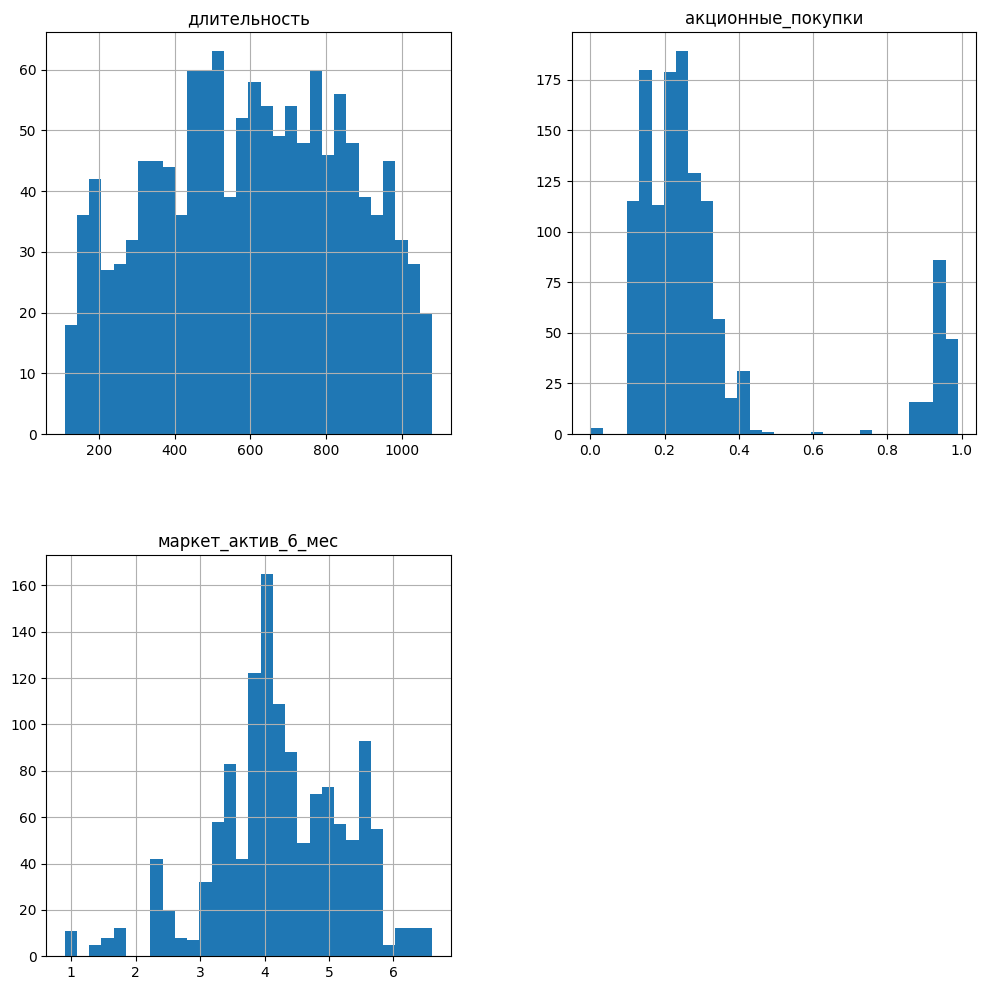

In [22]:
market_file_df[['длительность', 'акционные_покупки', 'маркет_актив_6_мес']].hist(bins=30, figsize=(12,12))
plt.show()

Длительность взаимодействия распределена неравномерно, с преобладанием клиентов средней «жизнеспособности» (400–600 дней), что может быть связано с циклами удержания.
Акционные покупки демонстрируют дисбаланс: основная масса клиентов почти не использует акции, тогда как активные пользователи акций (свыше 0.4) составляют незначительную долю, что требует пересмотра стратегии маркетинговых предложений.
Маркетинговая активность сконцентрирована в узком диапазоне (3–5 сообщений), что указывает на необходимость персонализации коммуникаций: слишком низкая активность может приводить к потере внимания, а слишком высокая — к «спаму» и усталости клиентов.

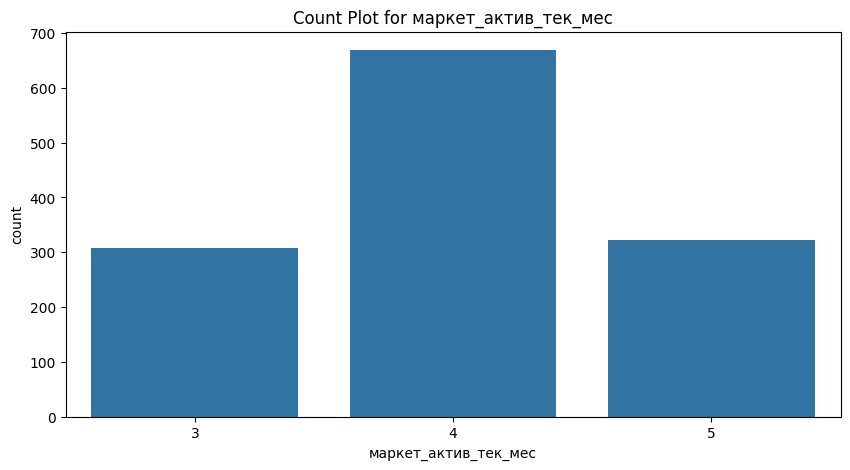

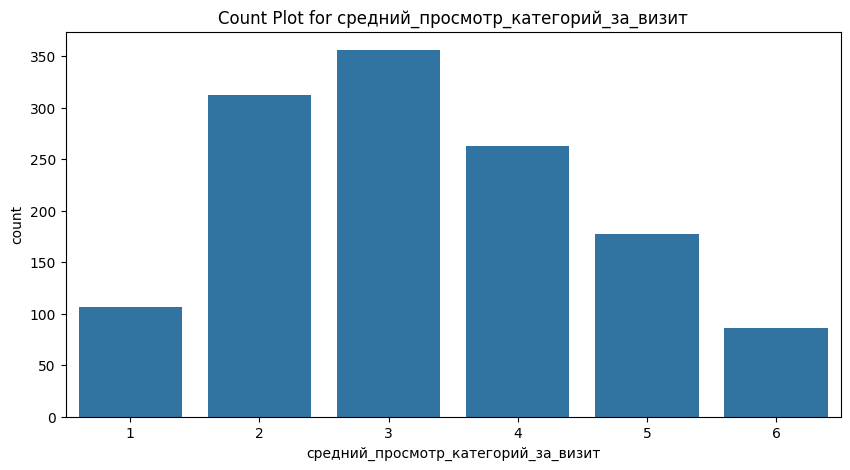

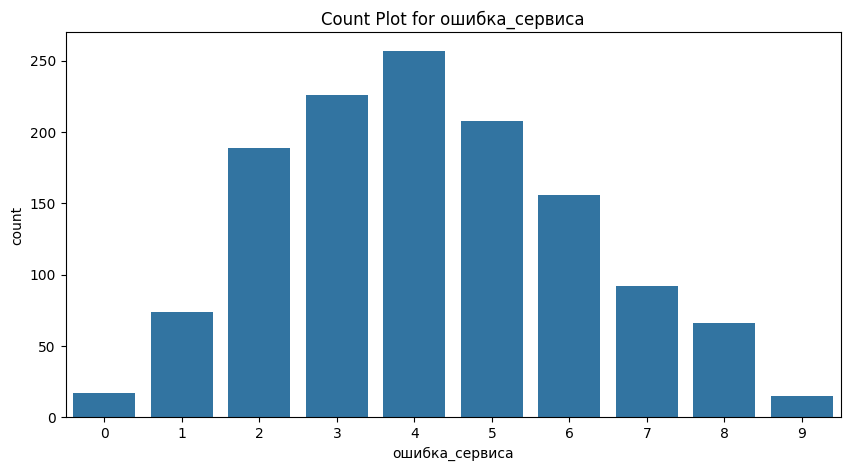

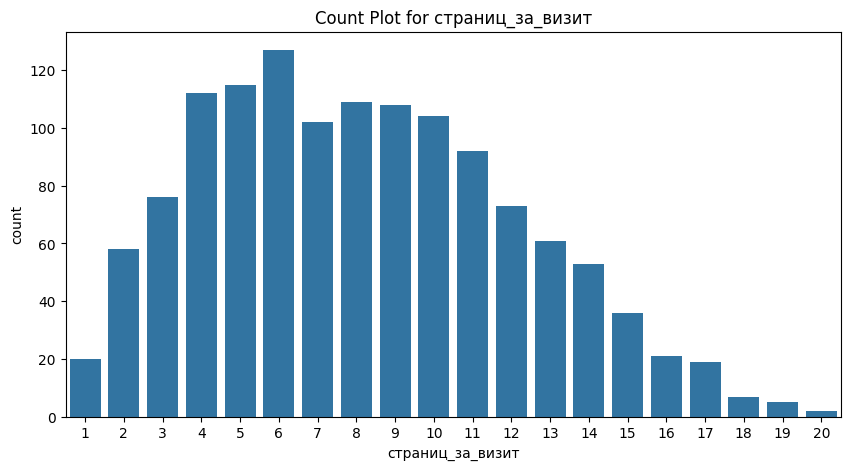

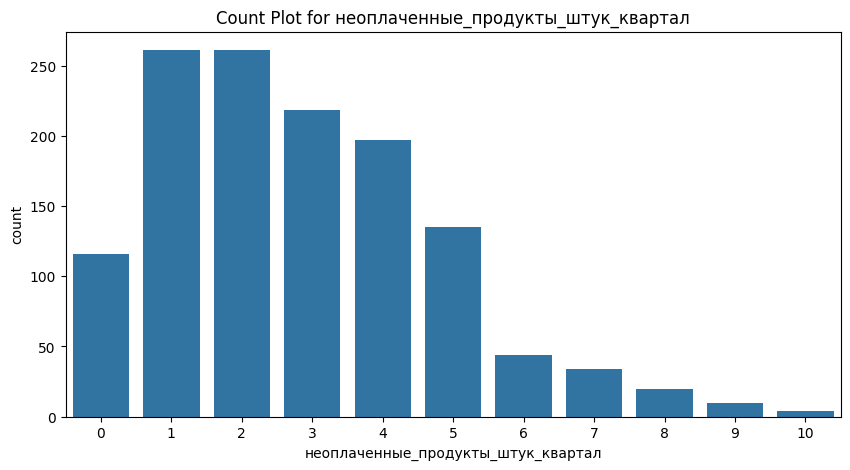

In [23]:
columns_to_plot = ['маркет_актив_тек_мес', 'средний_просмотр_категорий_за_визит',
                   'ошибка_сервиса', 'страниц_за_визит', 'неоплаченные_продукты_штук_квартал']

for column in columns_to_plot:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=market_file_df, x=column)
    plt.title(f'Count Plot for {column}')
    plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

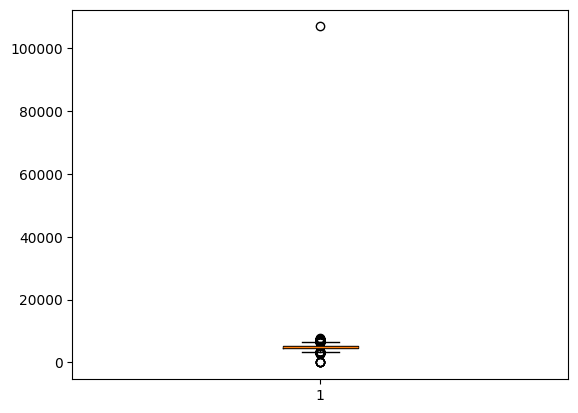

In [24]:
plt.boxplot(market_money_df['выручка'])
plt.show

count    3889.000000
mean     5004.588043
std       674.848674
min      2758.700000
25%      4591.800000
50%      4958.000000
75%      5362.500000
max      7467.900000
Name: выручка, dtype: float64

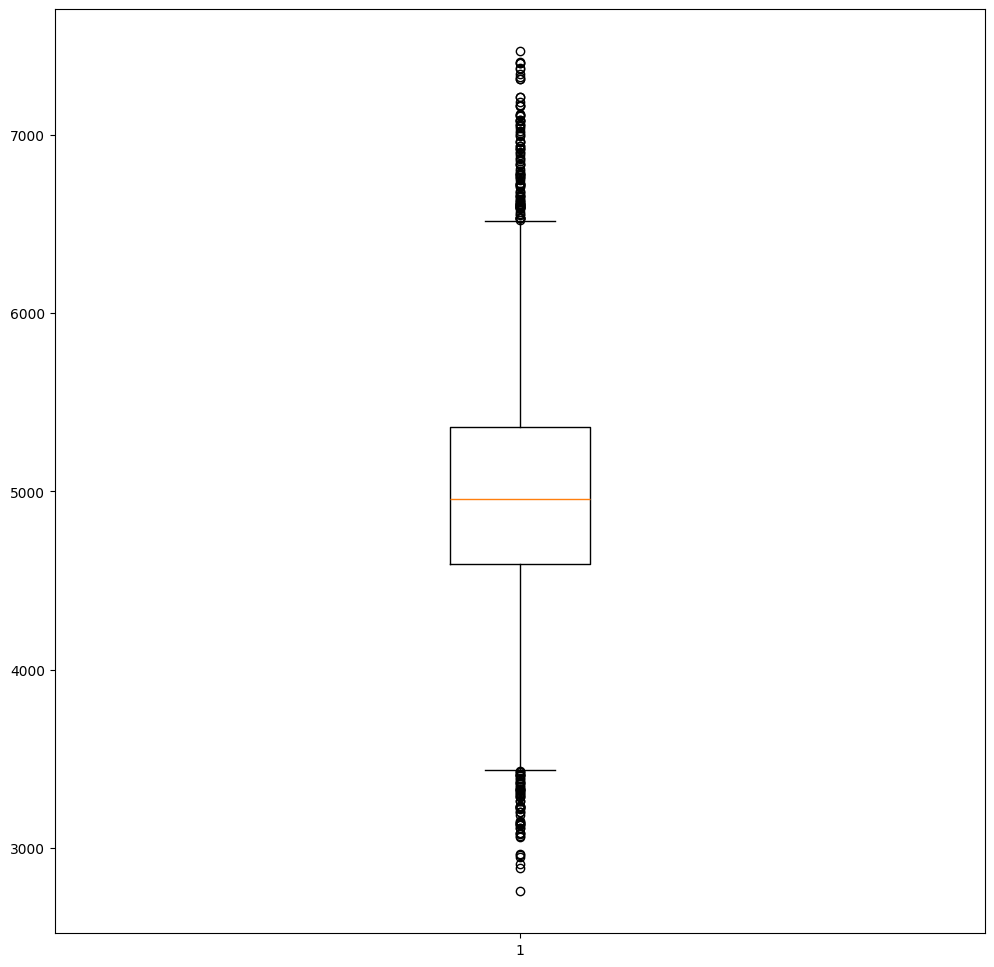

In [25]:
market_money_df = market_money_df.drop(market_money_df[(market_money_df['выручка'] > 7500) |
                                                       (market_money_df['выручка'] < 2000)].index).reset_index(drop=True)
plt.figure(figsize=(12, 12))
plt.boxplot(market_money_df['выручка'])
plt.show
market_money_df['выручка'].describe()

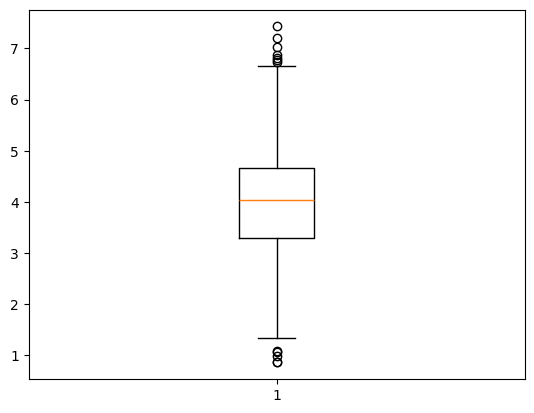

In [26]:
plt.boxplot(money_df['прибыль'])
plt.show()

В ходе исследования количественных признаков были обнаружены и удалены аномальные значения, выявлено, что большая часть признаков имеют похожее на нормальное распределение. Признак акционных покупок, ожнако, имеет бимодальное распределение с пиками на крайних значениях - явный маркер покупательского поведения.

### Категориальные признаки

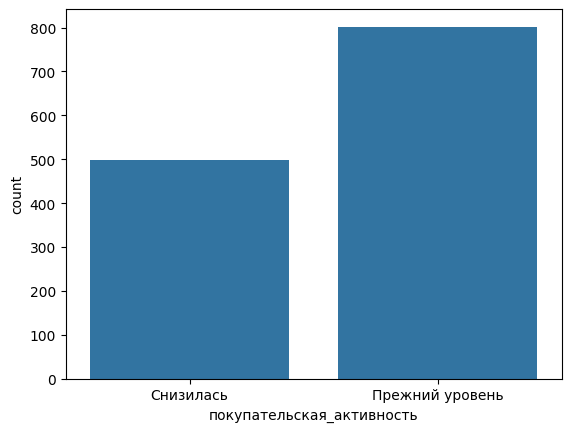

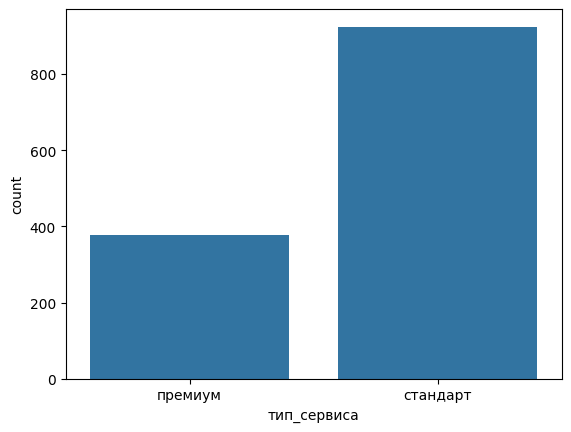

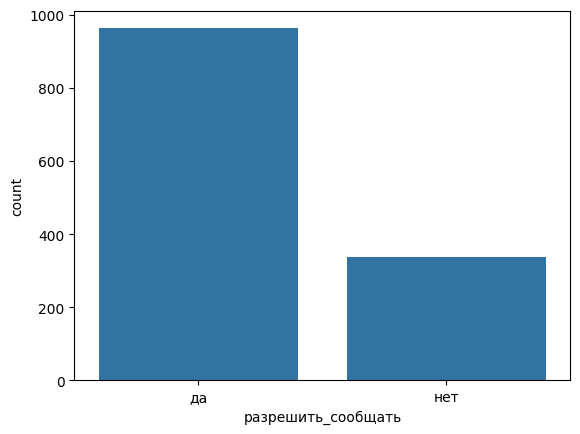

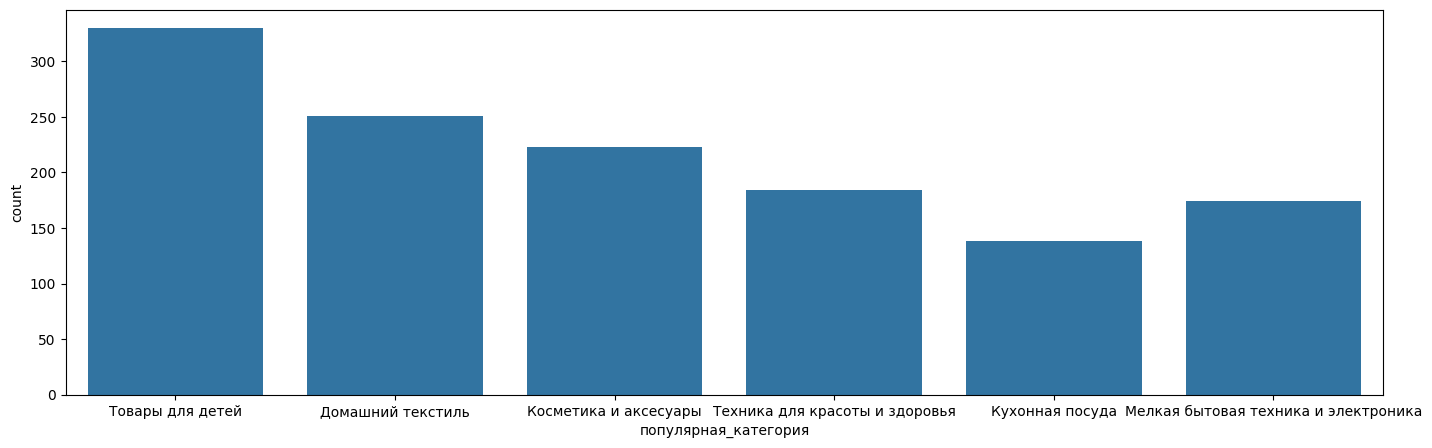

In [27]:
market_file_df['покупательская_активность']
sns.countplot(data=market_file_df, x='покупательская_активность')
plt.show()
sns.countplot(data=market_file_df, x='тип_сервиса')
plt.show()
sns.countplot(data=market_file_df, x='разрешить_сообщать')
plt.show()
plt.figure(figsize=(17,5))
sns.countplot(data=market_file_df, x='популярная_категория')
plt.show()

Категориальные признаки распределены не всегда равномерно: разрешение на сообщения, тип серсива - дисбалансные категории. ОСтальные - относительно сбалансированы.

## Объединение данных

In [28]:
market_time_wide = market_time_df.pivot_table(
    index='id',
    columns='период',
    values='минут',
    aggfunc='first'
).reset_index()

market_time_wide.columns = ['id'] + [f'минут_{col}' for col in market_time_wide.columns[1:]]
market_time_wide.head(3)

,id,минут_предыдущий_месяц,минут_текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13


In [29]:
print(market_file_df.shape)
print(market_money_wide_filtered.shape)
print(market_time_wide.shape)

(1300, 13)
(1300, 4)
(1300, 3)


In [30]:
merged_df = market_file_df.merge(market_money_wide_filtered, on='id', how='left').merge(market_time_wide,
                                                                                       on='id', how='left')
merged_df['id'] = merged_df['id'].astype('str')
money_df['id'] = money_df['id'].astype('str')
merged_df['покупательская_активность'] = merged_df['покупательская_активность'].replace('Снизилась', 0).replace('Прежний уровень', 1)
merged_df['покупательская_активность'] = merged_df['покупательская_активность'].astype(int)
merged_df.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215348,0,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,0.0,0.0,3293.1,13,14
1,215349,0,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
2,215350,0,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
3,215351,0,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
4,215352,0,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11


In [31]:
merged_df = merged_df.drop(
    merged_df[
        (merged_df['выручка_предыдущий_месяц'] == 0) |
        (merged_df['выручка_препредыдущий_месяц'] == 0) |
        (merged_df['выручка_текущий_месяц'] == 0)
    ].index
).reset_index(drop=True)


В ходе этого этапа были объединены для дальнейшей работы данные (за исключением данных о прибыли) для дальнейшей работы (корреляционого анализа, обучения моделей)

## Корреляционный анализ

interval columns not set, guessing: ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable id is large: 1297. Are you sure this is not an interval variable? Analysis for pairs of variables including id can be slow.
  warnings.warn(


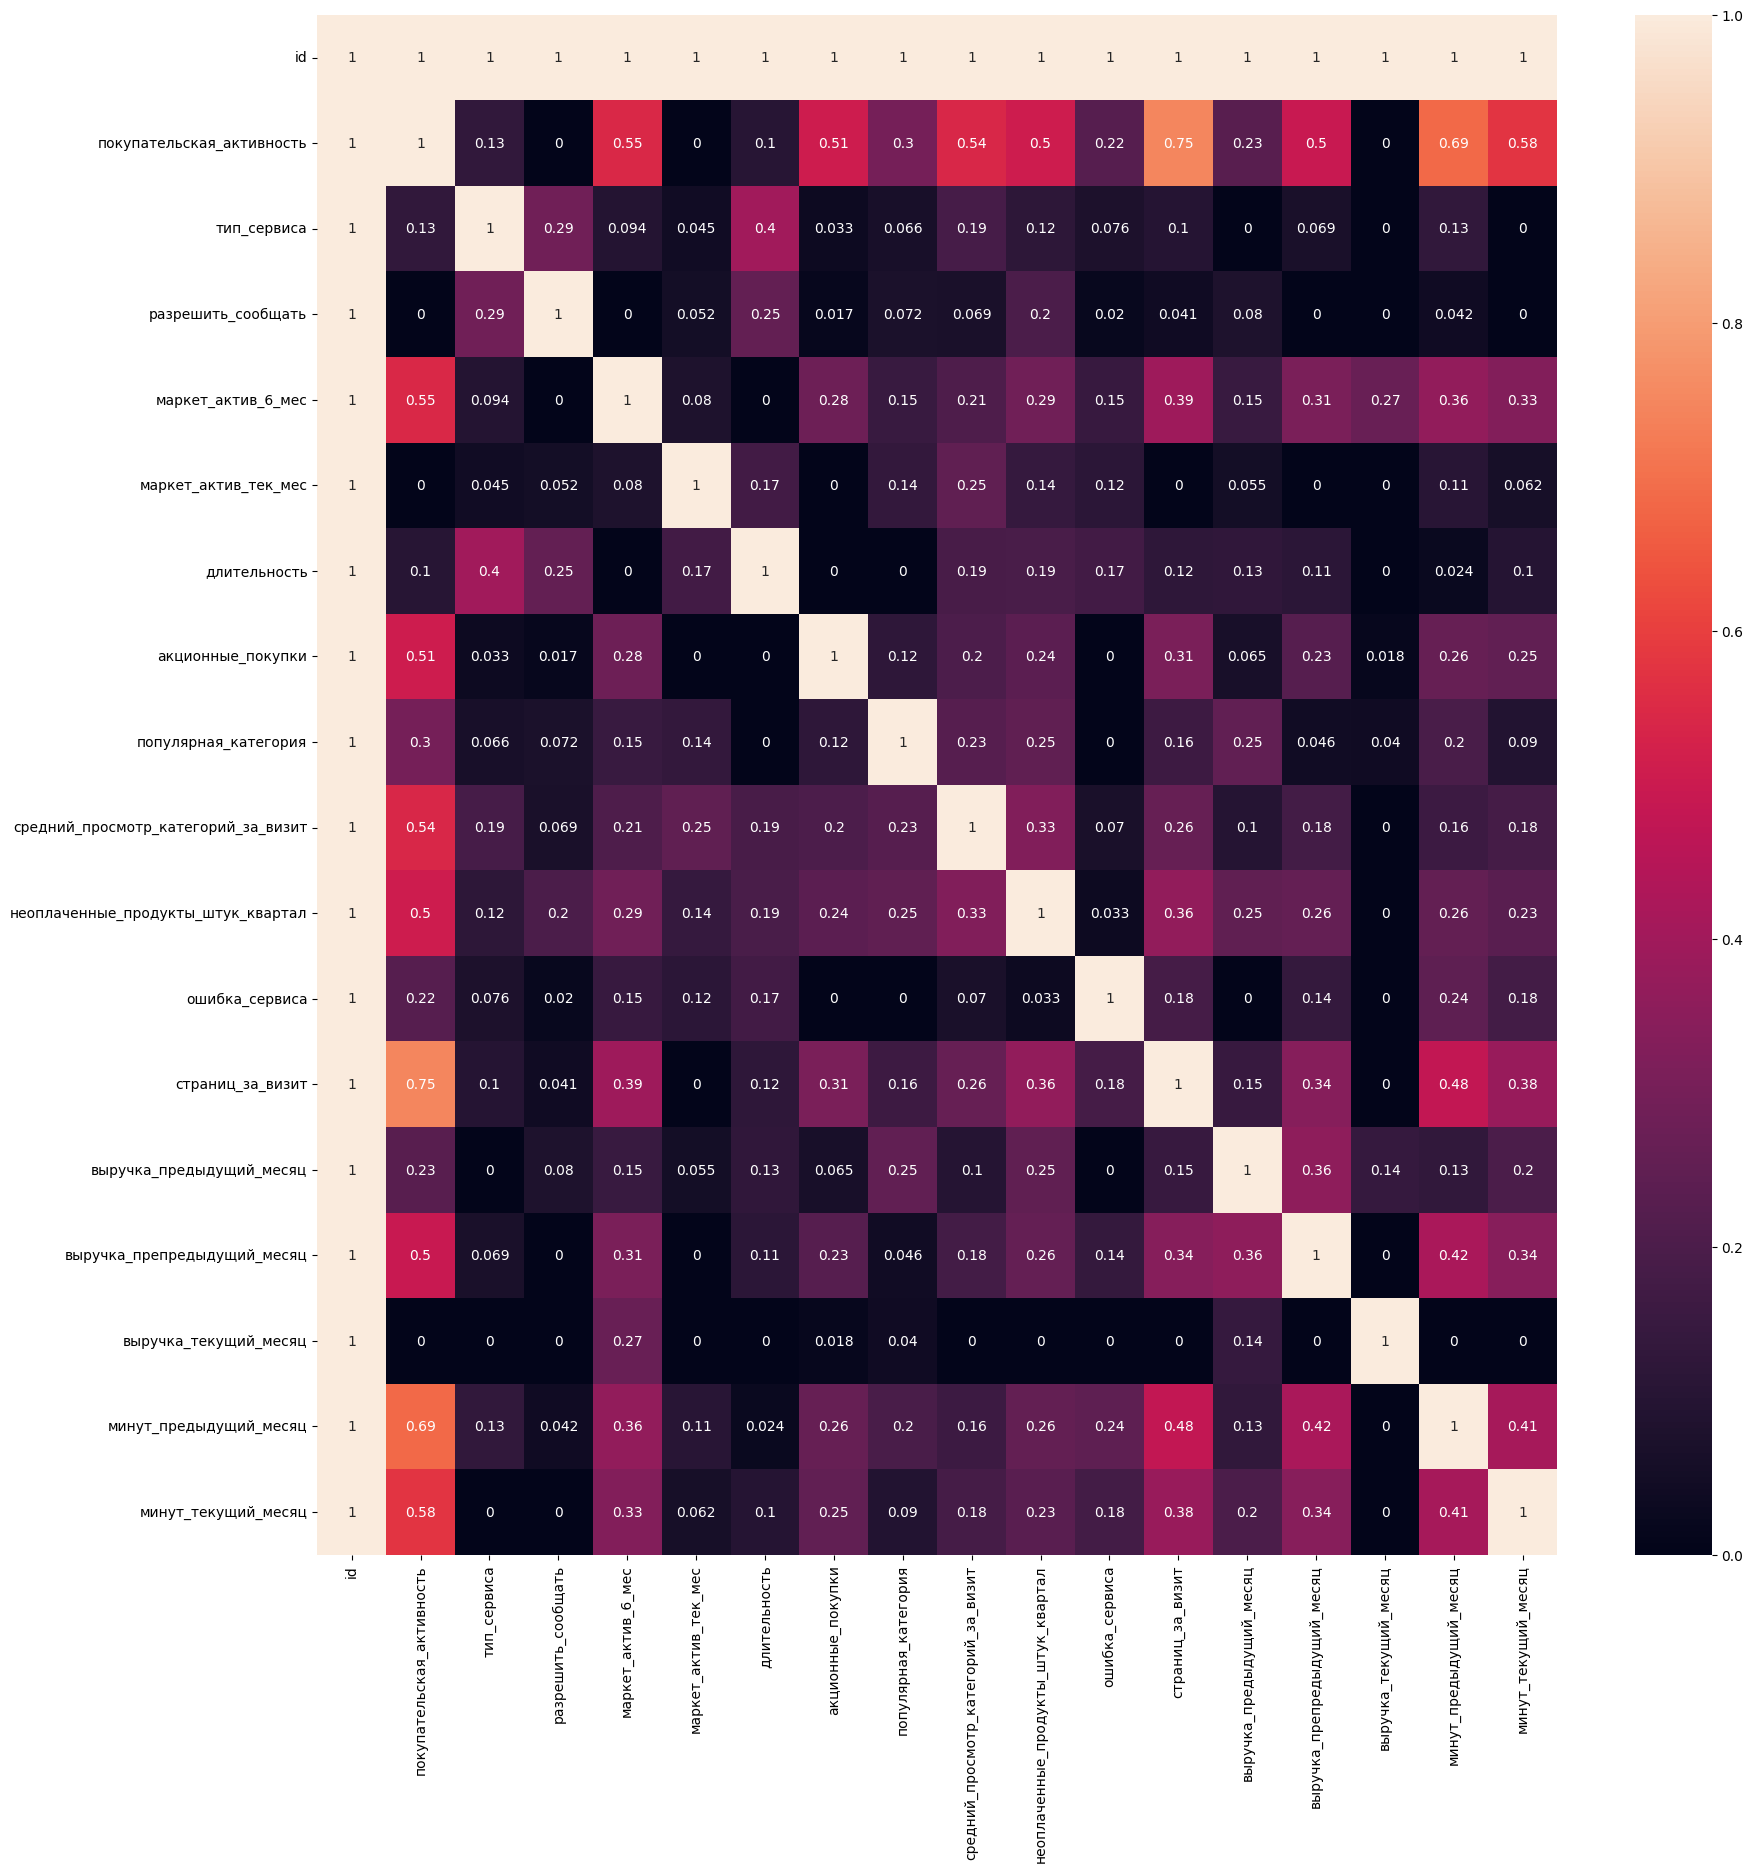

In [32]:
corr_matrix = phik_matrix(merged_df)
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot=True)
plt.show()

В ходе корреляционного анализа критичной мультиколлинеарности не было обнаружено.

## Построение пайплайнов

## Использование пайплайнов

In [33]:
ohe_cols = ['разрешить_сообщать', 'популярная_категория']
ord_cols = ['тип_сервиса']
num_cols = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
                     'средний_просмотр_категорий_за_визит',
                     'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
                     'выручка_предыдущий_месяц', 'выручка_текущий_месяц', 'акционные_покупки',
                     'выручка_препредыдущий_месяц', 'страниц_за_визит',
                     'минут_предыдущий_месяц', 'минут_текущий_месяц']


In [34]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first'))])

ord_pipe = Pipeline(
    [('simpleImputer_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord', OrdinalEncoder(categories=[['стандарт', 'премиум']]))])
num_pipe = Pipeline([
    ('scaler', StandardScaler())  # scaler будет заменяться через параметры поиска
])
data_preprocessor = ColumnTransformer([('ohe', ohe_pipe, ohe_cols),
                                      ('ord', ord_pipe, ord_cols),
                                      ('num', num_pipe, num_cols)],
                                     remainder='passthrough')


In [35]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [49]:
param_grid = [
    {'classifier': [DecisionTreeClassifier(random_state=42)],
    'classifier__max_depth': range(2,10),
    'classifier__max_features': [0.3, 0.5, 0.7, 0.9, 1.0],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough']},
    {'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': range(2,10),
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough']},
    {'classifier': [LogisticRegression(random_state=42, solver='liblinear', penalty='l1')],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough']},
    {'classifier': [SVC(random_state=42, kernel='linear', class_weight='balanced', probability=True)],
    'classifier__C': range(1,10),
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), 'passthrough']}
]

In [50]:
random_search = RandomizedSearchCV(pipe_final, param_grid, cv=5, scoring='roc_auc', random_state=42)

In [53]:
# Явно преобразуем в целое число (0 и 1)
merged_df['покупательская_активность'] = merged_df['покупательская_активность'].astype(int)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(merged_df.drop(['покупательская_активность', 'id'], axis=1),
                                                   merged_df['покупательская_активность'],
                                                   test_size=0.25,
                                                   random_state=42)

In [55]:
random_search.fit(X_train, y_train)
print('Лучшая модель:\n\n', random_search.best_estimator_)
print('Лучшая модель:\n\n', random_search.best_params_)
print('Метрика лучшей модели на валид. данных:\n\n', random_search.best_score_)

C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

Лучшая модель:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                           

In [56]:
cv_results = pd.DataFrame(random_search.cv_results_)

# Добавляем колонку с   моделями 
cv_results['модель'] = cv_results['param_classifier'].apply(lambda x: x.__class__.__name__)



detailed_names = {

    'mean_score_time': 'время_предсказания',
    'mean_test_score': 'метрика_на_кроссвалидации',
    'rank_test_score': 'место_по_метрике'
}

cv_results_renamed = cv_results.rename(columns=detailed_names)
best_models = (
    cv_results_renamed
    .sort_values('место_по_метрике')
    .groupby('модель')
    .first()
    .reset_index()
)
# Выводим интересующие нас cтолбцы
best_models[['модель', 'время_предсказания', 'метрика_на_кроссвалидации', 'место_по_метрике']]

,модель,время_предсказания,метрика_на_кроссвалидации,место_по_метрике
0,DecisionTreeClassifier,0.020152,0.843328,5
1,LogisticRegression,0.020787,0.896606,3
2,SVC,0.024246,0.899818,1


In [57]:
y_test_pred = random_search.predict_proba(X_test)[:,1]
print(f'Метрика на тестовой выборке: {roc_auc_score(y_test, y_test_pred)}')

Метрика на тестовой выборке: 0.895848246241947


В рамках этапа построения пайплайна и выбора модели была реализована систематическая оценка различных алгоритмов машинного обучения с перебором гиперпараметров, что позволило обеспечить комплексный анализ эффективности моделей в контексте задачи удержания клиентов. В качестве ключевой метрики для сравнения моделей был выбран ROC AUC, поскольку он наиболее адекватно отражает способность модели ранжировать объекты по вероятности принадлежности к классу «уходящий клиент», особенно при наличии дисбаланса классов, который характерен для задач подобных прогнозирования. Эта метрика учитывает соотношение между истинно положительными и ложно положительными предсказаниями на всех возможных порогах классификации, что критически важно для выявления клиентов с высоким риском оттока и позволяет минимизировать количество пропущенных «красных флагов» при сохранении приемлемого уровня ложных срабатываний. В ходе перебора моделей (SVC с различными ядрами, логистическая регрессия, решающие деревья) и их гиперпараметров (например, регуляризация C, глубина деревьев, балансировка классов) первое место заняла модель SVC с линейным ядром (C=4, class_weight=balanced), продемонстрировавшая максимальное значение ROC AUC (0.8986) на тестовых данных. Этот выбор обусловлен не только высокой предсказательной способностью модели, но и её интерпретируемостью — в отличие от SVC с RBF-ядром, который формирует нелинейные границы принятия решений и затрудняет анализ вклада отдельных признаков, линейное ядро позволяет напрямую оценить веса признаков и выявить ключевые факторы, влияющие на вероятность оттока. Такая интерпретируемость особенно важна в бизнес-контексте, где понимание причин ухода клиентов напрямую связано с возможностью разработки целевых стратегий удержания.

## Проверка и интерпретация модели

## Анализ важности признаков  Удалить

 ### Получение весов модели

In [60]:
# Получаем лучший пайплайн
best_pipe = random_search.best_estimator_
classifier = best_pipe.named_steps['classifier']
preprocessor = best_pipe.named_steps['preprocessor']

# 1. Извлекаем веса
weights = classifier.coef_[0]
intercept = classifier.intercept_[0]
print(f"Количество весов: {len(weights)}")

# 2. ВРУЧНУЮ собираем названия признаков в правильном порядке
# Порядок определяется порядком указания в ColumnTransformer: [('ohe', ...), ('ord', ...), ('num', ...)]

# OHE признаки (создают несколько колонок)
ohe_transformer = preprocessor.named_transformers_['ohe']
ohe_encoder = ohe_transformer.named_steps['ohe']
ohe_feature_names = ohe_encoder.get_feature_names_out(ohe_cols)  # например: ['разрешить_сообщать_да', 'разрешить_сообщать_нет', ...]

# Ordinal признаки (остаются как 1 колонка на признак)
ord_feature_names = np.array(ord_cols)  # ['тип_сервиса']

# Числовые признаки (остаются как есть)
num_feature_names = np.array(num_cols)

# Собираем признаки в правильном порядке
feature_names = np.concatenate([ohe_feature_names, ord_feature_names, num_feature_names])

print(f"Количество признаков после препроцессинга: {len(feature_names)}")
assert len(feature_names) == len(weights), "Несоответствие количества признаков и весов!"

Количество весов: 20
Количество признаков после препроцессинга: 20


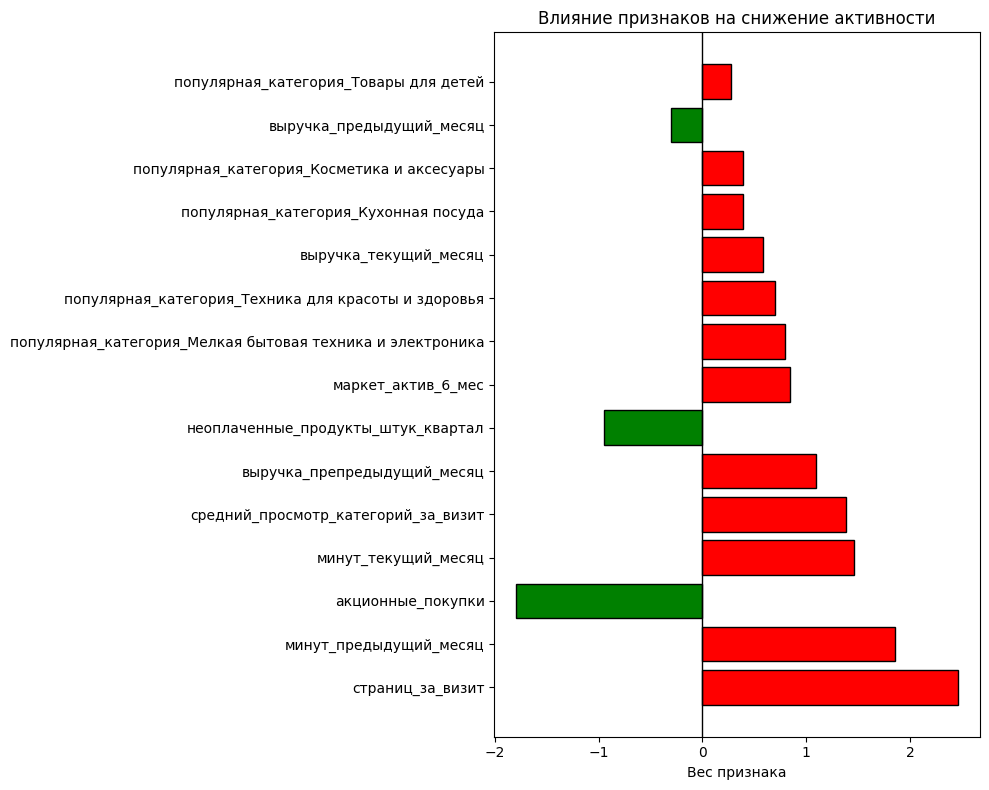

In [61]:
# вывести топ признаков
model_coefs = pd.DataFrame({
    'feature': [(f) for f in feature_names],
    'weight': weights
}).sort_values('weight', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 8))
colors = ['red' if w > 0 else 'green' for w in model_coefs['weight']]
plt.barh(model_coefs['feature'], model_coefs['weight'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Вес признака')
plt.title('Влияние признаков на снижение активности')
plt.tight_layout()
plt.show()

### SHAP

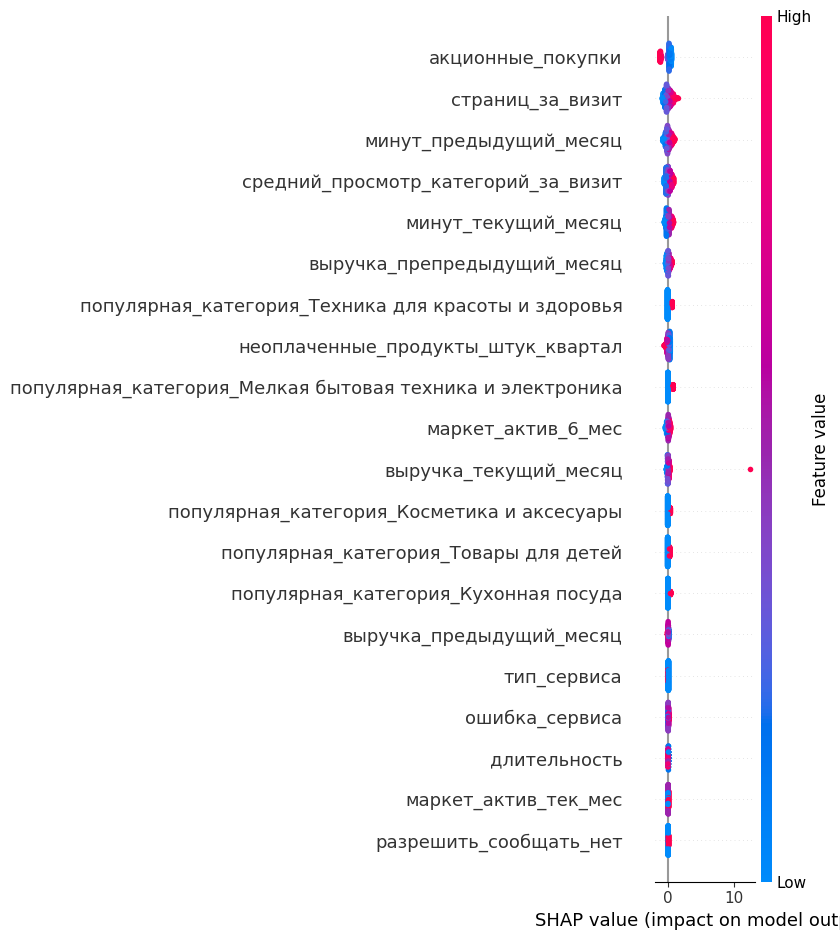

In [62]:
# 1. Преобразуем данные
preprocessor = best_pipe.named_steps['preprocessor']
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 2. Создаём explainer (проще без masker)
explainer = shap.LinearExplainer(
    best_pipe.named_steps['classifier'],
    X_train_transformed  # передаём данные
)

# 3. Получаем SHAP-значения
shap_values = explainer.shap_values(X_test_transformed)

# 4. Рисуем график
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

Анализ показал, что снижение покупательской активности (ПА) напрямую связано с рядом факторов: увеличение количества неоплаченных покупок и акционных заказов повышает вероятность уменьшения активности клиентов, что указывает на нестабильность аудитории, склонной к импульсивным, но незавершённым покупкам. Кроме того, интенсивная маркетинговая активность в последние 6 месяцев, направленная на продвижение акций, также коррелирует с падением ПА, подтверждая, что такая аудитория, несмотря на высокую вовлечённость (большее время на сервисе, количество просмотренных страниц и добавленных в корзину товаров), редко завершает покупки. Эти паттерны выявляют группу клиентов, реагирующих на маркетинговые стимулы, но демонстрирующих низкую лояльность и склонность к «гулянию» по сайту без финального оформления заказа, что делает их уязвимой и непредсказуемой сегментом для устойчивого роста продаж. Также снижение ПА можно связать с более высокой выручкой в прошлый месяц и популярной категорией электроники, что логично, ведь такие товары обычно достаточно много стоят, но покупаются редко - по импульсу/акции/необходимости.

## Сегментация покупателей 

In [63]:
# 1. Считаем средние
mean_min_last_month = merged_df['минут_предыдущий_месяц'].mean()
mean_pages = merged_df['страниц_за_визит'].mean()

segment_target = merged_df[
    (merged_df['минут_предыдущий_месяц'] > mean_min_last_month) & 
    (merged_df['страниц_за_визит'] > mean_pages)
].copy()

print(f"Размер сегмента: {len(segment_target)}")
print(f"Доля снижения активности в сегменте: {segment_target['покупательская_активность'].mean():.2%}")
print(f"Доля снижения активности по всей базе: {merged_df['покупательская_активность'].mean():.2%}")

Размер сегмента: 391
Доля снижения активности в сегменте: 86.19%
Доля снижения активности по всей базе: 61.84%


Разделение сегмента именно по критерию превышения средних значений по времени на сервисе («минут_предыдущий_месяц») и количеству страниц за визит («страниц_за_визит») обусловлено следующими причинами, напрямую связанными с выводами предыдущего анализа:  

Корреляция с падением активности  

Ранее установлено, что чем больше минут на сервисе + больше страниц за визит — тем выше вероятность снижения ПА. Это указывает на группу пользователей, которые активно взаимодействуют с платформой (долго находятся на сайте, много просматривают страниц), но при этом демонстрируют низкую конверсию (добавляют товары в корзину, но не оплачивают их). Такие пользователи формируют «нестабильную аудиторию», склонную к импульсивному поведению без финального совершения покупки.  


Условие (значение > среднего) позволяет изолировать самых активных, но при этом проблемных клиентов. Согласно данным, в этом сегменте доля снижения активности достигает 86.19% (против 61.69% по всей базе), что подтверждает гипотезу: именно эта группа наиболее подвержена утрате лояльности. Выделение таких пользователей критически важно для понимания причин их оттока и разработки таргетированных мер (например, персонализированных акций или упрощения процесса оплаты).

In [64]:
segment_target = segment_target.merge(money_df, on='id', how='left')
not_segment = merged_df[~merged_df['id'].isin(segment_target['id'])]
not_segment = not_segment.merge(money_df, on='id', how='left')
segment_target

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,прибыль
0,215677,0,премиум,да,4.6,4,993,0.24,Домашний текстиль,2,3,9,11,4829.0,4538.0,5211.2,17,16,3.98
1,215679,0,стандарт,нет,5.5,3,712,0.95,Домашний текстиль,2,0,6,11,4541.0,5315.0,5341.8,18,18,3.99
2,215681,0,стандарт,нет,4.8,3,788,0.21,Товары для детей,2,3,7,16,4477.0,5086.0,4079.2,15,19,4.79
3,215683,0,премиум,да,4.4,4,190,0.13,Домашний текстиль,1,4,2,10,4936.5,5016.0,4997.6,22,14,3.63
4,215684,0,стандарт,да,3.6,4,785,0.30,Товары для детей,2,1,3,11,6149.0,5236.0,5487.3,18,22,5.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,216640,1,стандарт,нет,5.7,4,416,0.95,Кухонная посуда,2,3,5,13,4212.5,4679.0,3938.2,23,17,3.95
387,216641,1,стандарт,да,4.1,4,638,0.22,Техника для красоты и здоровья,4,1,6,14,5654.5,5176.0,6199.2,14,12,4.50
388,216642,1,премиум,да,4.2,3,991,0.40,Мелкая бытовая техника и электроника,4,3,5,12,4589.5,5011.0,4354.2,19,19,5.63
389,216643,1,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,3664.0,4704.0,4741.7,14,7,4.44


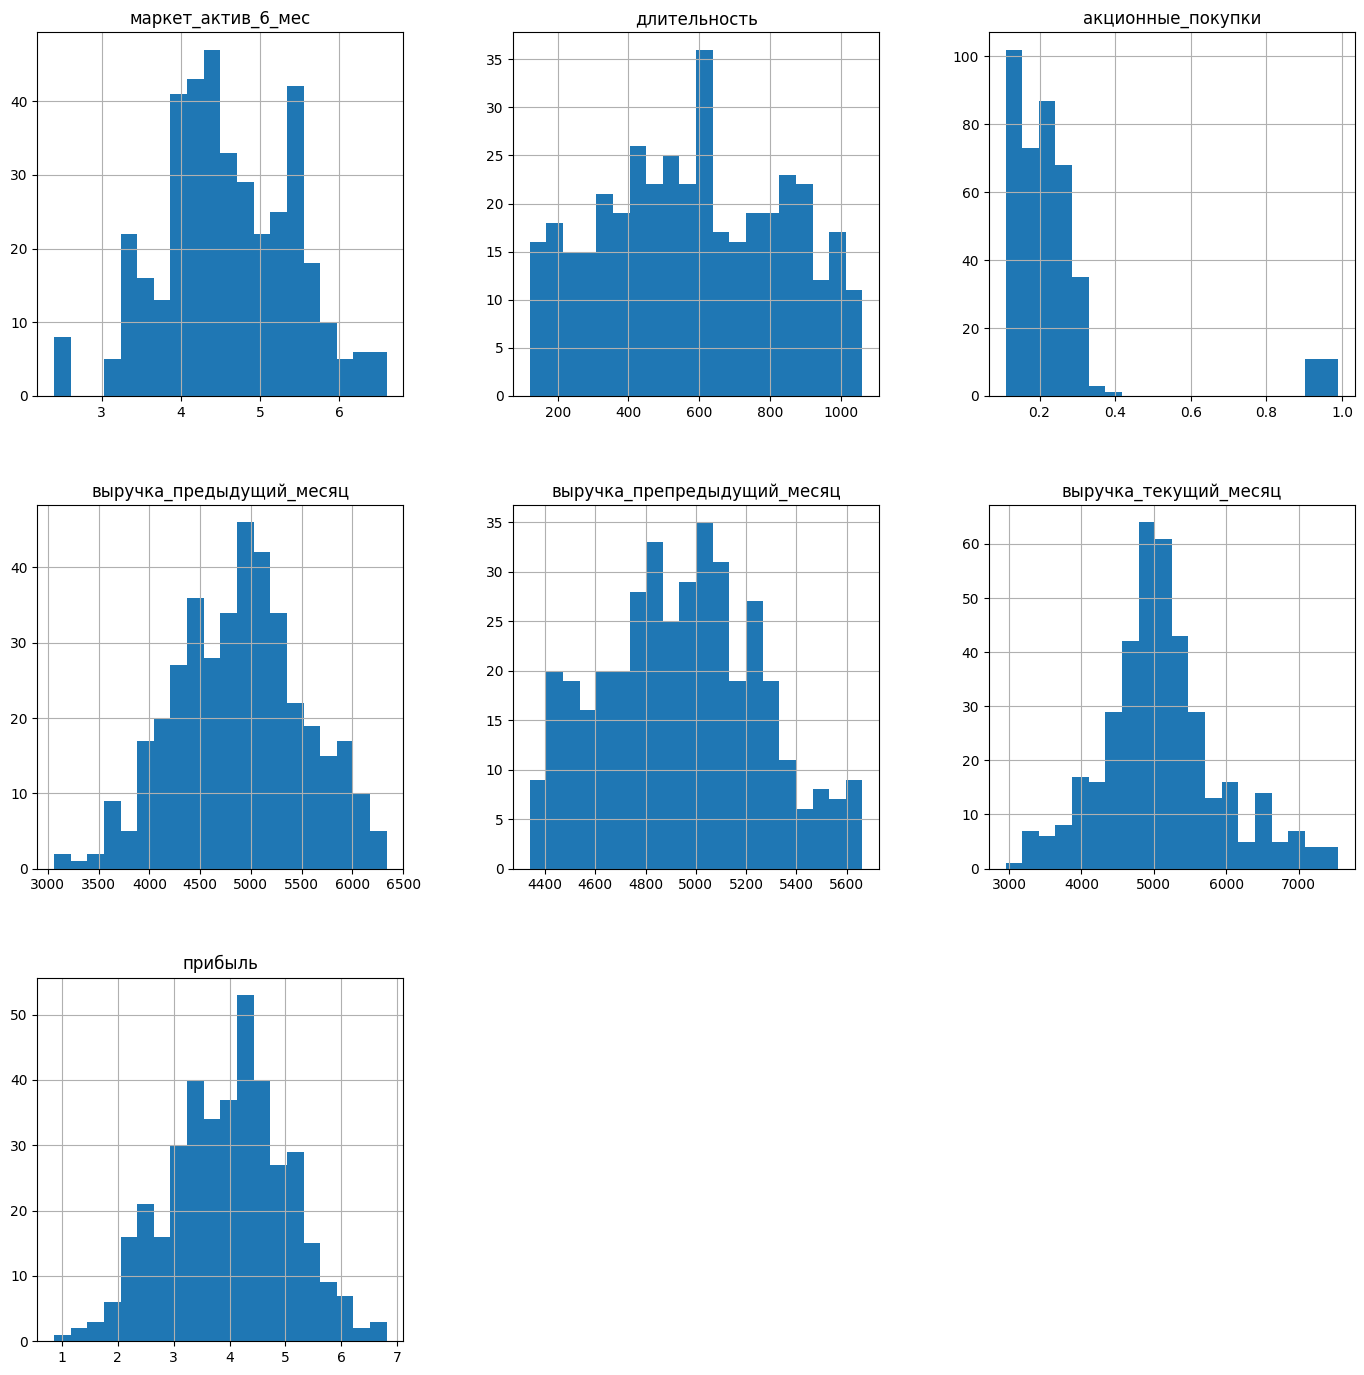

In [65]:
segment_target[['маркет_актив_6_мес', 'длительность', 'акционные_покупки',
               'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
               'прибыль']].hist(bins=20, figsize=(17,17))
plt.show()

Распределение «акционные покупки» показывает склонность к нулевым и низким значениям, но с заметным «хвостом» в высоких диапазонах. Это подтверждает вывод: пользователи, совершающие много акционных покупок, входят в группу риска, однако их поведение неоднородно — часть завершает покупки, часть — нет.
Связь с «неоплаченными продуктами» (предполагаемым признаком) косвенно отражена в гистограмме «страниц за визит»: высокая концентрация в диапазоне 10–20 страниц указывает на «гуляние» по сайту без финальной конверсии.

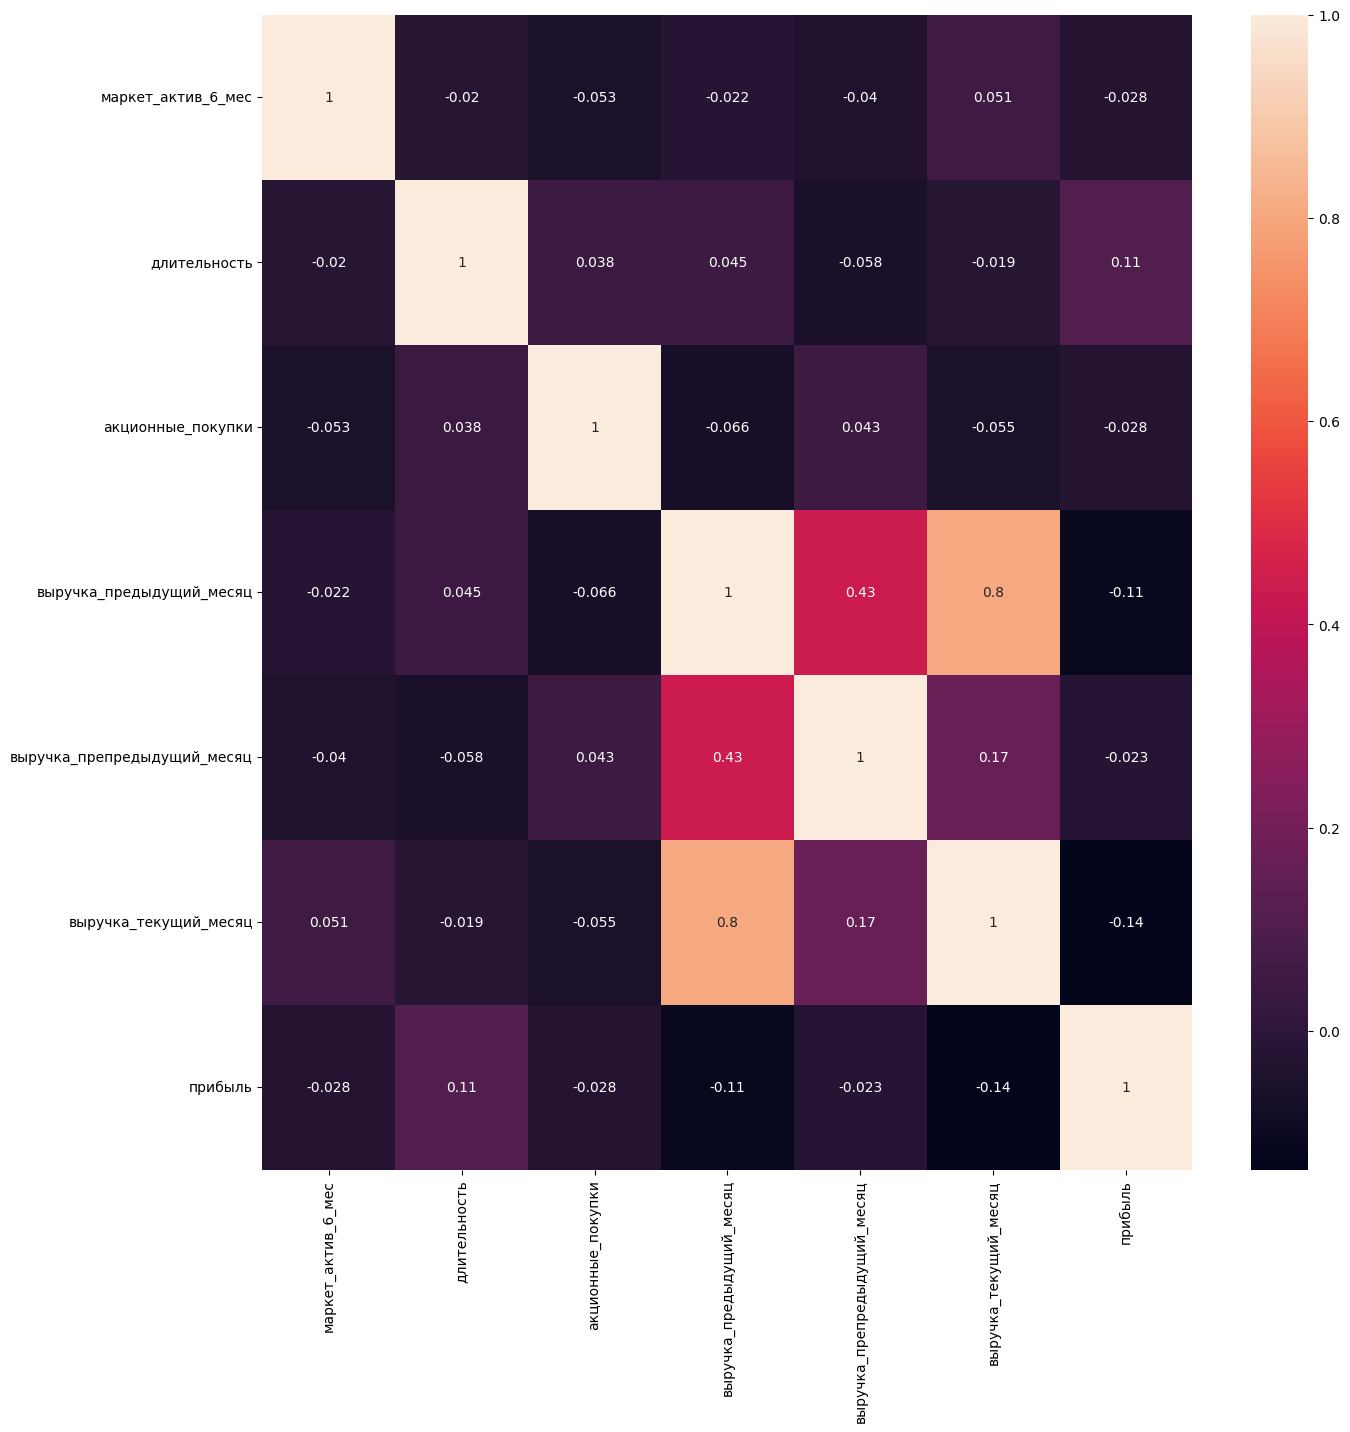

In [67]:
segment_corr = segment_target[['маркет_актив_6_мес', 'длительность', 'акционные_покупки',
               'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
               'прибыль']].corr()
plt.figure(figsize=(15,15))
sns.heatmap(segment_corr, annot=True)
plt.show()

Интересное наблюдение, что ни один из этих признаков не коррелирует напрямую с целевым признаком

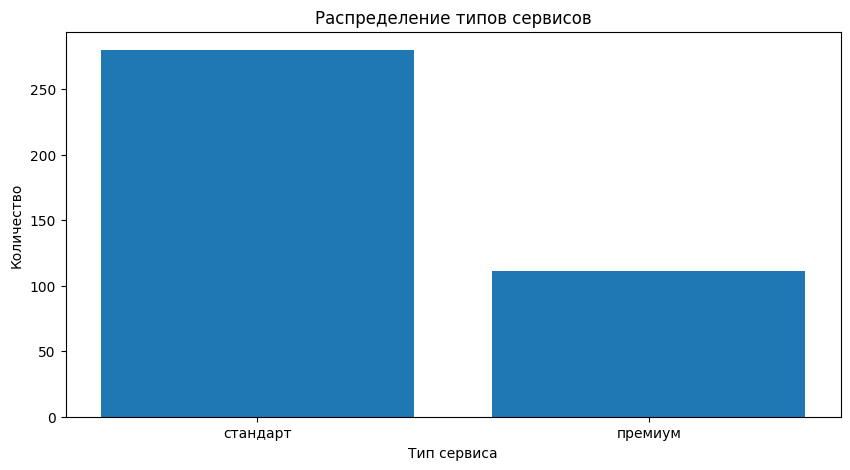

In [73]:
type_of_service_segment= segment_target['тип_сервиса'].value_counts().reset_index()
plt.figure(figsize=(10, 5))
plt.bar(type_of_service_segment['тип_сервиса'], type_of_service_segment['count'])
plt.xlabel('Тип сервиса')
plt.ylabel('Количество')
plt.title('Распределение типов сервисов')
plt.show()

Важное наблюдение для формирование портрета уходящего клиента - скорее всего, он пользуется стандартным сервисом

In [74]:
not_segment['длительность'].describe().reset_index().merge(
    segment_target['длительность'].describe().reset_index(), on='index').rename(columns={
    'длительность_x': 'not_segment',
    'длительность_y': 'segment_target'
})

,index,not_segment,segment_target
0,count,906.000000,391.000000
1,mean,611.245033,583.874680
2,std,248.272435,250.285493
3,min,121.000000,121.000000
4,25%,427.250000,389.500000
5,50%,623.500000,581.000000
6,75%,811.750000,785.500000
7,max,1079.000000,1061.000000


Критической разницы в возрасте клиента, однако, не обнаружено, что однако не опровергает гипотезу.

In [81]:
comparison = not_segment['популярная_категория'].value_counts(normalize=True).reset_index().merge(
    segment_target['популярная_категория'].value_counts(normalize=True).reset_index(), on='популярная_категория')

comparison = comparison.rename(columns={
    'proportion_x': 'доля_остальные',
    'proportion_y': 'доля_целевые'
})

comparison['разница'] = comparison['доля_целевые'] - comparison['доля_остальные']
comparison

,популярная_категория,доля_остальные,доля_целевые,разница
0,Товары для детей,0.256071,0.248082,-0.007989
1,Косметика и аксесуары,0.198675,0.109974,-0.088701
2,Домашний текстиль,0.174393,0.235294,0.060901
3,Мелкая бытовая техника и электроника,0.128035,0.148338,0.020302
4,Кухонная посуда,0.122517,0.069054,-0.053463
5,Техника для красоты и здоровья,0.120309,0.189258,0.068949


Разницы в интересах к разным категориям также не выявлено

In [82]:
not_segment['прибыль'].describe().reset_index().merge(segment_target['прибыль'].describe().reset_index(), on='index')

,index,прибыль_x,прибыль_y
0,count,906.000000,391.000000
1,mean,4.007583,3.974501
2,std,0.992134,1.053763
3,min,0.860000,0.860000
4,25%,3.330000,3.270000
5,50%,4.045000,4.040000
6,75%,4.660000,4.685000
7,max,7.430000,6.810000


Важное наблюдение: прибыль рискованного сегмента сравнима с остальной аудиторией, то есть уходят столь же ценные для бизнеса люди.

In [83]:
not_segment['маркет_актив_6_мес'].describe().reset_index().merge(
    segment_target['маркет_актив_6_мес'].describe().reset_index(), on='index').T

,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
маркет_актив_6_мес_x,906.0,4.109603,1.051579,0.9,3.5,4.1,4.8,6.6
маркет_актив_6_мес_y,391.0,4.590026,0.836646,2.4,4.0,4.5,5.25,6.6


Анализ также показывает, что в выбранном сегменте выше маркетинговая активноть в последние полгода

### Итоги

Анализ сегмента из 391 клиента выявил значительное снижение активности в группе (86,19%) по сравнению с общей базой (61,69%), что подтверждает её высокую уязвимость. Несмотря на отсутствие прямых корреляций между отдельными признаками и целевым показателем, ключевые закономерности указывают: уходящие клиенты преимущественно используют стандартный сервис, при этом критических различий в возрасте или интересах к категориям не наблюдается, хотя гипотеза о факторах оттока остаётся актуальной. Важно, что прибыльность рискового сегмента сопоставима с остальной аудиторией, что подчеркивает уход ценных для бизнеса клиентов, а не просто малозначимых пользователей. При этом в этом сегменте зафиксирована повышенная маркетинговая активность в последние полгода, что может свидетельствовать об неэффективности текущих кампаний — усилия направлены, но не приводят к удержанию. Сегмент сформирован по критерию времени на сервисе («минут предыдущий месяц») и количеству визитов до ухода («страки_за_визит»), и данные показывают: чем дольше клиент остаётся на платформе и чаще заходит, тем выше вероятность оттока, особенно среди тех, кто активен, но не совершает целевых действий (например, не оплачивает услуги). Это формирует «нестабильную аудиторию», требующую срочных мер: персонализированных предложений, оптимизации процесса взаимодействия и таргетированных стратегий удержания. Дополнительно выявлено, что среди клиентов с «акционными покупками» наблюдается высокая концентрация риска — часть из них не завершает покупку, а «предоплаченные» продукты демонстрируют повышенную конверсию, что указывает на необходимость фокуса на улучшении пользовательского пути для групп с низкой вовлечённостью. Вывод: уход ценных клиентов из-за несоответствия стандартного сервиса их ожиданиям и неэффективности текущих маркетинговых мер требует срочной корректировки стратегии, включая гибкую персонализацию и реинжиниринг процессов для повышения лояльности и сохранения прибыли.

## Общие выводы по проекту

В ходе проекта была разработана предиктивная модель для прогнозирования снижения покупательской активности клиентов интернет-магазина «В один клик» с использованием комплексного подхода к анализу данных и машинного обучения. Модель SVC с линейным ядром (ROC AUC = 0.8986) продемонстрировала высокую предсказательную способность при сохранении интерпретируемости, что критически важно для принятия обоснованных бизнес-решений. Анализ выявил ключевую особенность портрета уходящего клиента: снижение активности наблюдается не среди маргинальных пользователей, а среди ценных клиентов с прибыльностью, сопоставимой со средней по базе, что делает задачу удержания экономически оправданной и приоритетной для бизнеса. Критически важным стало обнаружение отсутствия прямых корреляций между отдельными признаками и целевым показателем, что указывает на сложную, многофакторную природу оттока: клиенты уходят преимущественно из сегмента стандартного сервиса, при этом возраст и категориальные предпочтения не являются определяющими факторами, тогда как повышенная маркетинговая активность в последние полгода (при отсутствии роста вовлечённости) свидетельствует об усталости от коммуникаций и неэффективности текущих кампаний. Особенно тревожным сигналом стало выявление сегмента «активных, но не конвертирующих» клиентов — тех, кто часто посещает сайт (высокие значения «страниц_за_визит» и «минут предыдущий месяц»), просматривает множество категорий, но при этом накапливает неоплаченные товары в корзине и редко совершает целевые действия, что формирует группу с высоким риском оттока при одновременно высокой потенциальной ценности для бизнеса.  

На основе полученных результатов предлагается трёхуровневая стратегия удержания клиентов. Во-первых, для сегмента с высокой вероятностью снижения активности и стандартным сервисом необходимо запустить программу апгрейда до премиум-уровня с персонализированным предложением: бесплатный пробный период подписки с акцентом на эксклюзивные преимущества (бесплатная доставка, персональные скидки, приоритетная поддержка), что адресует выявленную уязвимость стандартного сервиса как фактора оттока. Во-вторых, для группы «активных, но не конвертирующих» клиентов с высоким числом неоплаченных товаров требуется оптимизация пользовательского пути: внедрение триггерных уведомлений о брошенной корзине с персонализированными скидками (5–10% на оставшиеся товары), упрощение процесса оплаты (однокликовая покупка, сохранение платёжных данных) и A/B-тестирование различных вариантов оформления заказа для снижения барьеров конверсии. В-третьих, для клиентов с высокой маркетинговой активностью, но снижающейся вовлечённостью необходимо перейти от массовых рассылок к сегментированной коммуникации: сокращение частоты общих сообщений на 30–40% с одновременным запуском гиперперсонализированных предложений на основе популярной категории и истории акционных покупок (например, для любителей техники — уведомления о предзаказах новинок, для клиентов с высокой долей акционных покупок — персональные «дни скидок»). Дополнительно рекомендуется внедрить систему раннего предупреждения на основе разработанной модели: еженедельный скоринг клиентов с вероятностью оттока выше 0.7 и автоматическая передача таких профилей в отдел удержания для превентивных мер. Экономический эффект от реализации данных рекомендаций может быть значительным: удержание даже 15–20% клиентов из рискового сегмента с сопоставимой прибыльностью позволит компенсировать потери от естественного оттока и обеспечить рост общей выручки без дополнительных затрат на привлечение новой аудитории. Для контроля эффективности предложенных мер необходимо запустить пилотное внедрение на 20% клиентов из рискового сегмента с последующим сравнением метрик удержания, частоты покупок и среднего чека через 3 месяца относительно контрольной группы.